In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r"C:\Users\Basnet\data.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
print(df.isnull().sum())   # Count missing per column

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [4]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Age'] = df['Age'].astype(int)

In [5]:
df.drop('Cabin', axis=1, inplace=True)

In [6]:
df.dropna(subset=['Embarked'], inplace=True)

In [7]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

In [8]:
df['Fare'] = df['Fare'].round().astype(int)
df['Fare'] = '$' + df['Fare'].astype(str)

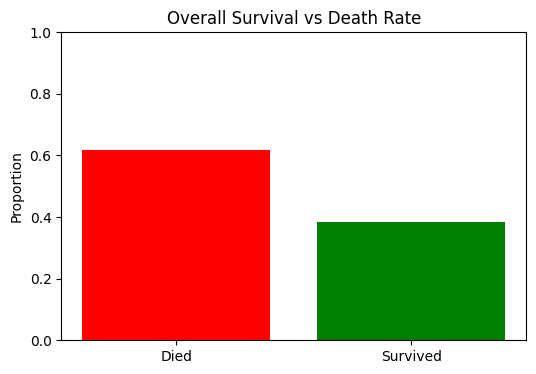

In [9]:
import matplotlib.pyplot as plt

survived_rate = df['Survived'].mean()
death_rate = 1 - survived_rate  

labels = ['Died', 'Survived']
values = [death_rate, survived_rate]

plt.figure(figsize=(6, 4))
plt.bar(labels, values, color=['red', 'green'])
plt.title('Overall Survival vs Death Rate')
plt.ylabel('Proportion')
plt.ylim(0, 1)
plt.show()

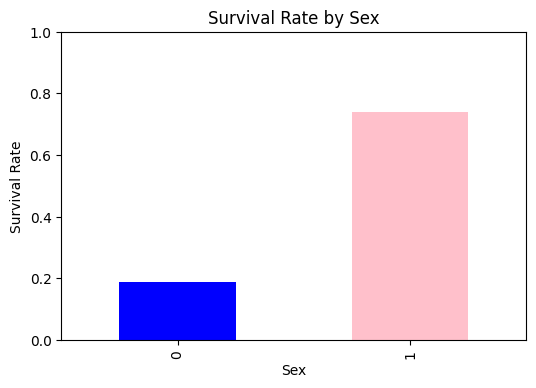

In [10]:
sex_survival = df.groupby('Sex')['Survived'].mean()

plt.figure(figsize=(6,4))
sex_survival.plot(kind='bar', color=['blue', 'pink'])
plt.title('Survival Rate by Sex')
plt.ylabel('Survival Rate')
plt.ylim(0,1)
plt.show()

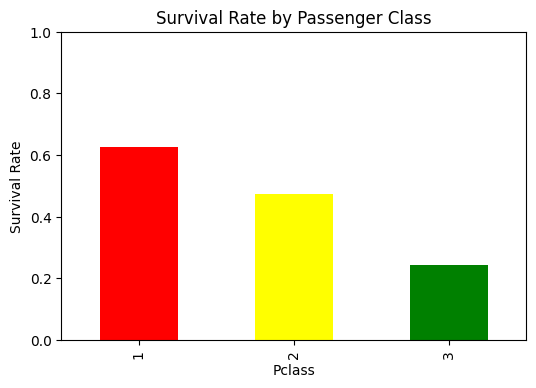

In [11]:
class_survival = df.groupby('Pclass')['Survived'].mean()

plt.figure(figsize=(6,4))
class_survival.plot(kind='bar',color=['red','yellow','green'])
plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Rate')
plt.ylim(0,1)
plt.show()

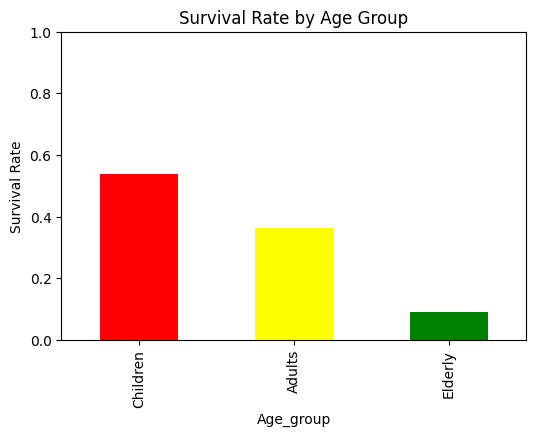

In [12]:
def classify_age(age):
    if age <= 17:
        return 'Children'
    elif age <= 64:
        return 'Adults'
    else:
        return 'Elderly'

df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Age_group'] = df['Age'].map(classify_age)  

age_survival = df.groupby('Age_group')['Survived'].mean().reindex(['Children', 'Adults', 'Elderly'])

plt.figure(figsize=(6,4))
age_survival.plot(kind='bar', color=['red', 'yellow', 'green'])
plt.title('Survival Rate by Age Group') 
plt.ylabel('Survival Rate')
plt.ylim(0,1)
plt.show()


In [13]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_group
0,1,0,3,"Braund, Mr. Owen Harris",0,22,1,0,A/5 21171,$7,S,Adults
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38,1,0,PC 17599,$71,C,Adults
2,3,1,3,"Heikkinen, Miss. Laina",1,26,0,0,STON/O2. 3101282,$8,S,Adults
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35,1,0,113803,$53,S,Adults
4,5,0,3,"Allen, Mr. William Henry",0,35,0,0,373450,$8,S,Adults
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27,0,0,211536,$13,S,Adults
887,888,1,1,"Graham, Miss. Margaret Edith",1,19,0,0,112053,$30,S,Adults
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,28,1,2,W./C. 6607,$23,S,Adults
889,890,1,1,"Behr, Mr. Karl Howell",0,26,0,0,111369,$30,C,Adults
